# Market Flows & Canton Migrations

Visualize Swiss corporate dynamics: company registrations, dissolutions,
and legal-seat migrations between cantons. Requires VynCo API v3.1+
(`/analytics/flows` and `/analytics/migrations`).

```bash
pip install vynco matplotlib seaborn
```

In [1]:
import os
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import vynco

sns.set_theme(style="whitegrid", font_scale=1.1)
ACCENT = "#2e86ab"
POS = "#44bba4"
NEG = "#e94f37"
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

client = vynco.Client()
print(f"VynCo SDK v{vynco.__version__} — connected")

VynCo SDK v3.0.0 — connected


## 1. Registrations vs Dissolutions Over Time

Aggregate flow across all cantons, showing the net company formation rate.

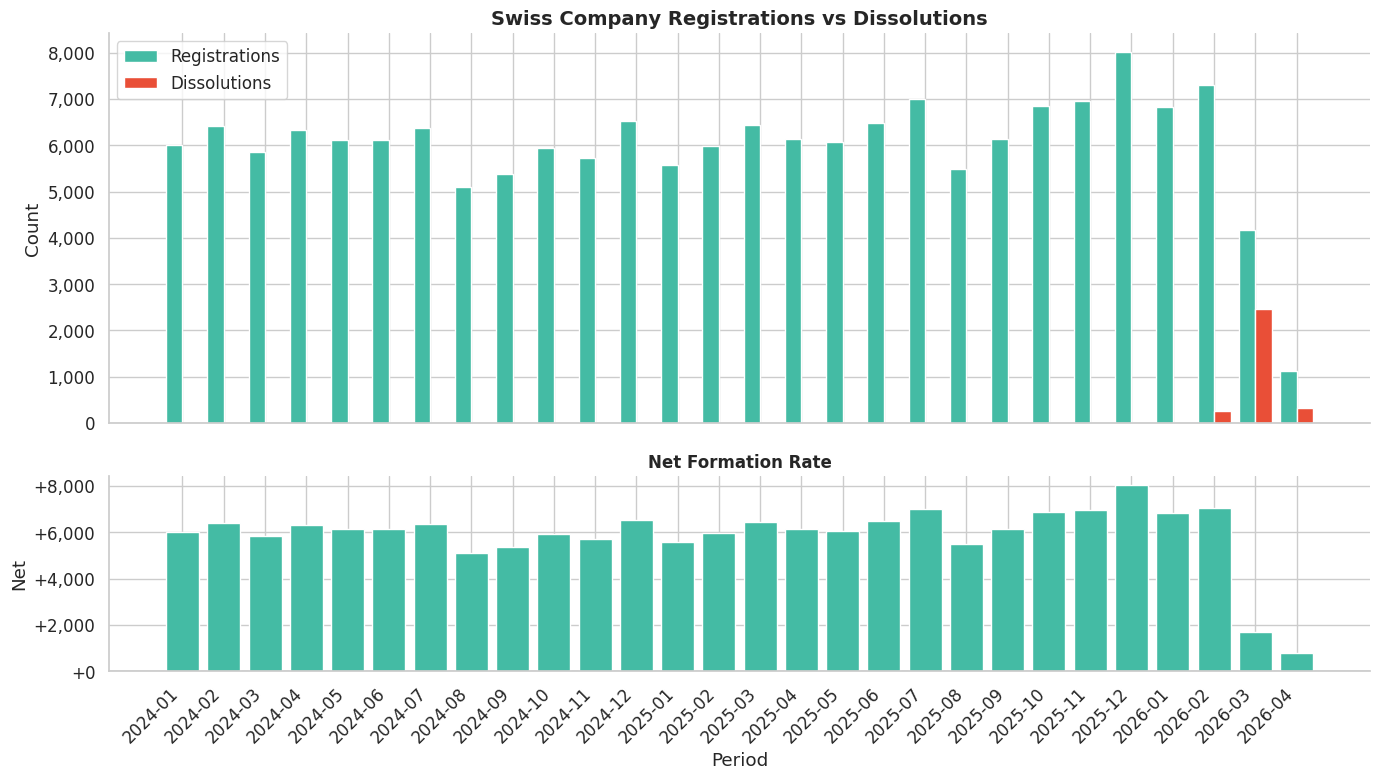

In [2]:
flows = client.analytics.flows(period="monthly", since="2024-01-01").data

# Aggregate across groups by period
by_period: dict[str, dict[str, int]] = defaultdict(lambda: {"reg": 0, "dis": 0, "net": 0})
for f in flows.flows:
    by_period[f.period]["reg"] += f.registrations
    by_period[f.period]["dis"] += f.dissolutions
    by_period[f.period]["net"] += f.net

periods = sorted(by_period.keys())
regs = [by_period[p]["reg"] for p in periods]
diss = [by_period[p]["dis"] for p in periods]
nets = [by_period[p]["net"] for p in periods]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

x = range(len(periods))
width = 0.4
ax1.bar([i - width / 2 for i in x], regs, width, label="Registrations",
        color=POS, edgecolor="white")
ax1.bar([i + width / 2 for i in x], diss, width, label="Dissolutions",
        color=NEG, edgecolor="white")
ax1.set_ylabel("Count")
ax1.set_title("Swiss Company Registrations vs Dissolutions",
              fontsize=14, fontweight="bold")
ax1.legend(loc="upper left")
ax1.spines[["top", "right"]].set_visible(False)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Net formation rate
colors = [POS if n >= 0 else NEG for n in nets]
ax2.bar(x, nets, color=colors, edgecolor="white")
ax2.axhline(y=0, color="#333", linewidth=0.8)
ax2.set_ylabel("Net")
ax2.set_xlabel("Period")
ax2.set_xticks(list(x))
ax2.set_xticklabels([p[:7] for p in periods], rotation=45, ha="right")
ax2.set_title("Net Formation Rate", fontsize=12, fontweight="bold")
ax2.spines[["top", "right"]].set_visible(False)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:+,.0f}"))

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/market_flows.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Canton Migrations

Which cantons are gaining or losing companies through legal-seat migrations?

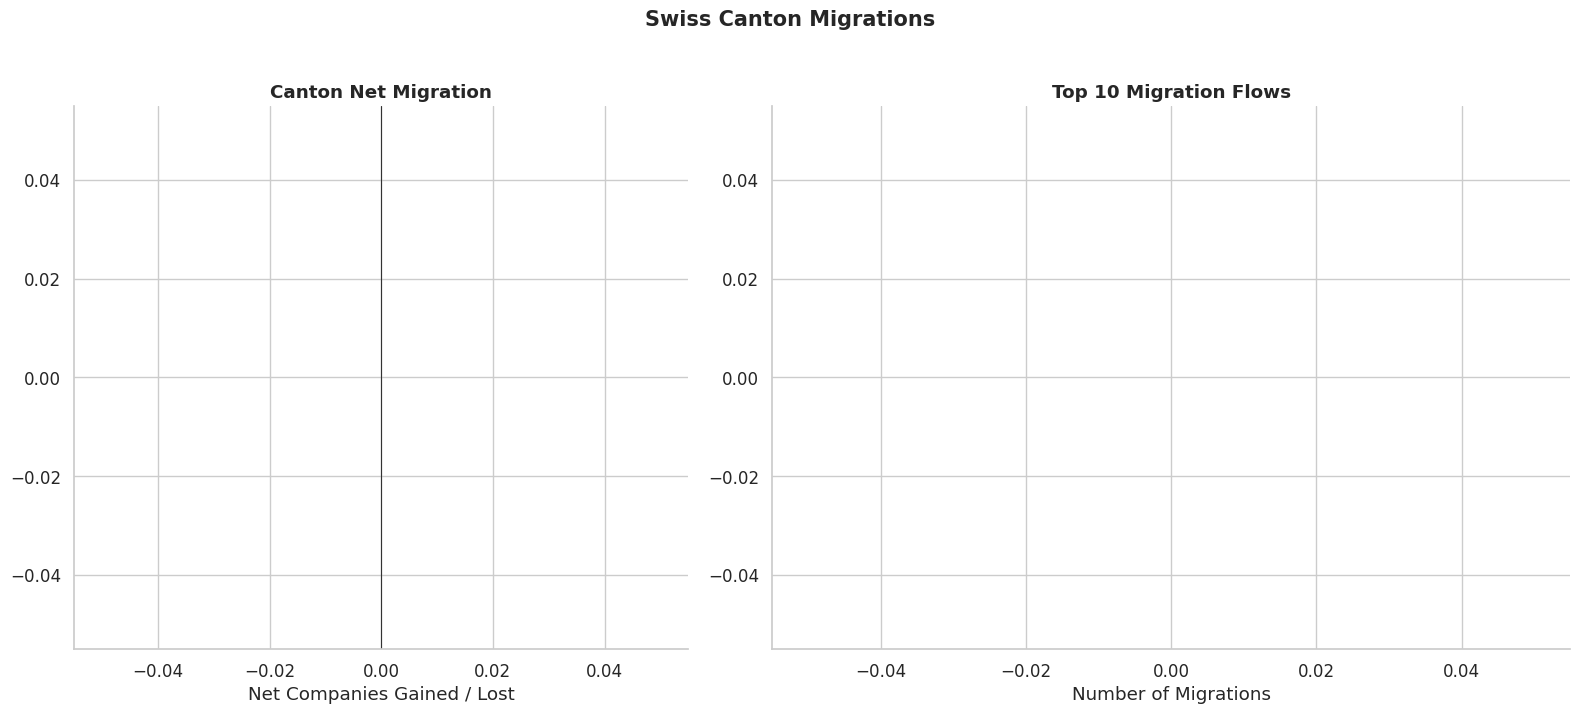

In [3]:
migrations = client.analytics.migrations(since="2024-01-01").data

# Net gain/loss per canton
net_by_canton: dict[str, int] = defaultdict(int)
for m in migrations.flows:
    net_by_canton[m.to_canton] += m.count
    net_by_canton[m.from_canton] -= m.count

sorted_net = sorted(net_by_canton.items(), key=lambda x: x[1])
cantons = [c for c, _ in sorted_net]
nets = [n for _, n in sorted_net]
bar_colors = [NEG if n < 0 else POS for n in nets]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7),
                                gridspec_kw={"width_ratios": [1, 1.3]})

# Net gains/losses
ax1.barh(cantons, nets, color=bar_colors, edgecolor="white")
ax1.axvline(x=0, color="#333", linewidth=0.8)
ax1.set_xlabel("Net Companies Gained / Lost")
ax1.set_title("Canton Net Migration", fontweight="bold")
ax1.spines[["top", "right"]].set_visible(False)

# Top 10 migration flows
top = migrations.top_flows[:10]
flow_labels = [f"{m.from_canton} → {m.to_canton}" for m in top]
flow_counts = [m.count for m in top]
ax2.barh(flow_labels[::-1], flow_counts[::-1], color=ACCENT, edgecolor="white")
ax2.set_xlabel("Number of Migrations")
ax2.set_title("Top 10 Migration Flows", fontweight="bold")
ax2.spines[["top", "right"]].set_visible(False)

plt.suptitle("Swiss Canton Migrations", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/canton_migrations.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Industry Flow Heatmap

Which industries are growing or shrinking? Break down flows by industry.

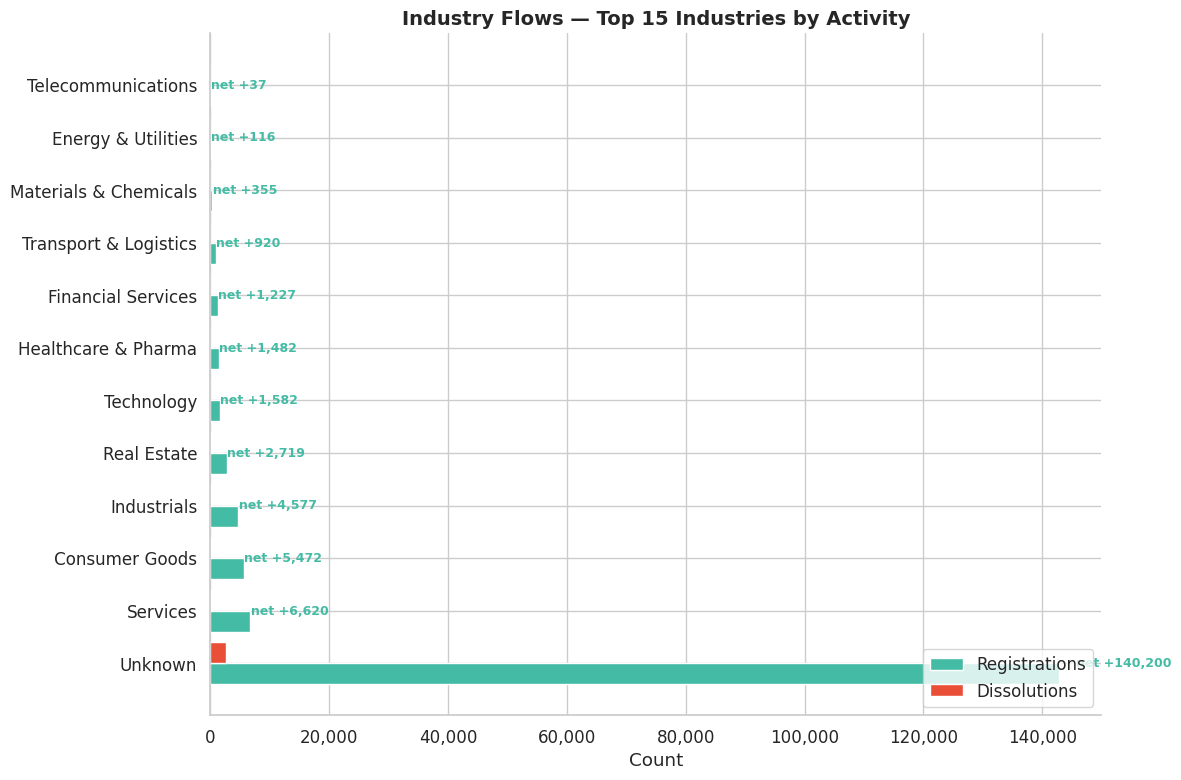

In [4]:
industry_flows = client.analytics.flows(
    period="quarterly", since="2024-01-01", group_by="industry"
).data

# Aggregate total registrations/dissolutions per industry
by_industry: dict[str, dict[str, int]] = defaultdict(lambda: {"reg": 0, "dis": 0})
for f in industry_flows.flows:
    by_industry[f.group]["reg"] += f.registrations
    by_industry[f.group]["dis"] += f.dissolutions

# Rank by total activity
ranked = sorted(by_industry.items(),
                key=lambda x: -(x[1]["reg"] + x[1]["dis"]))[:15]

industries = [i for i, _ in ranked]
regs = [v["reg"] for _, v in ranked]
diss = [v["dis"] for _, v in ranked]
net = [r - d for r, d in zip(regs, diss)]

fig, ax = plt.subplots(figsize=(12, 8))
y = range(len(industries))
ax.barh([i - 0.2 for i in y], regs, 0.4, label="Registrations",
        color=POS, edgecolor="white")
ax.barh([i + 0.2 for i in y], diss, 0.4, label="Dissolutions",
        color=NEG, edgecolor="white")

# Net labels
for i, n in enumerate(net):
    color = POS if n >= 0 else NEG
    ax.text(max(regs[i], diss[i]) * 1.02, i, f"net {n:+,}",
            va="center", fontsize=9, fontweight="bold", color=color)

ax.set_yticks(list(y))
ax.set_yticklabels(industries)
ax.set_xlabel("Count")
ax.set_title("Industry Flows — Top 15 Industries by Activity",
             fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/industry_flows.png", dpi=150, bbox_inches="tight")
plt.show()